In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import matplotlib.patches as mp
import dvx_ext
dvx_ext.build_type()

'Release'

0.0625


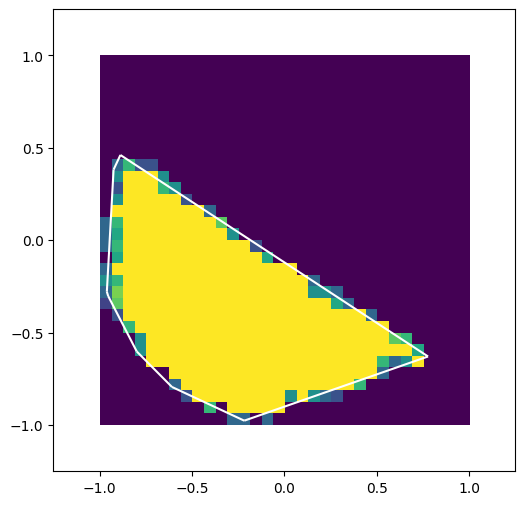

In [235]:
np.random.seed(0)
φ = np.sort(np.random.rand(8) * 2 * np.pi)
vertices = np.stack([np.cos(φ), np.sin(φ)], axis=-1)
edges    = np.arange(len(φ)) 
edges    = np.stack([edges, np.roll(edges, -1)], axis=-1)

grid = np.zeros((32, 32), dtype=np.float32)
dvx_ext.voxelize_f32(vertices, edges, grid, num_samples_per_voxel=1, filter_radius=0.0625)

print(2 / grid.shape[0])

domain_scale = 1.25
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_ylim(-1*domain_scale, 1*domain_scale)
ax.set_xlim(-1*domain_scale, 1*domain_scale)
ax.add_collection(mc.LineCollection(vertices[edges], color='white'))
ax.imshow(grid, extent=(-1, 1, 1, -1))

In [15]:
grid.min(), grid.max()

(np.float32(-2.1515096e-05), np.float32(1.0000005))